In [525]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [526]:
df = pd.read_csv("kidney_disease.csv")
df.shape

(400, 26)

In [527]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [528]:
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [529]:
df['age'].unique()

array([48.,  7., 62., 51., 60., 68., 24., 52., 53., 50., 63., 40., 47.,
       61., 21., 42., 75., 69., nan, 73., 70., 65., 76., 72., 82., 46.,
       45., 35., 54., 11., 59., 67., 15., 55., 44., 26., 64., 56.,  5.,
       74., 38., 58., 71., 34., 17., 12., 43., 41., 57.,  8., 39., 66.,
       81., 14., 27., 83., 30.,  4.,  3.,  6., 32., 80., 49., 90., 78.,
       19.,  2., 33., 36., 37., 23., 25., 20., 29., 28., 22., 79.])

In [530]:
df['age'].median()

55.0

In [531]:
df['age'] = df['age'].fillna(df['age'].median())
df['age'].unique()

array([48.,  7., 62., 51., 60., 68., 24., 52., 53., 50., 63., 40., 47.,
       61., 21., 42., 75., 69., 55., 73., 70., 65., 76., 72., 82., 46.,
       45., 35., 54., 11., 59., 67., 15., 44., 26., 64., 56.,  5., 74.,
       38., 58., 71., 34., 17., 12., 43., 41., 57.,  8., 39., 66., 81.,
       14., 27., 83., 30.,  4.,  3.,  6., 32., 80., 49., 90., 78., 19.,
        2., 33., 36., 37., 23., 25., 20., 29., 28., 22., 79.])

In [532]:
df['age'].isnull().sum()

np.int64(0)

In [533]:
df['bp'].unique()

array([ 80.,  50.,  70.,  90.,  nan, 100.,  60., 110., 140., 180., 120.])

In [534]:
df['bp'].mean()

np.float64(76.46907216494846)

In [535]:
df['bp'] = df['bp'].fillna(df['bp'].mean())
df['bp'].unique()

array([ 80.        ,  50.        ,  70.        ,  90.        ,
        76.46907216, 100.        ,  60.        , 110.        ,
       140.        , 180.        , 120.        ])

In [536]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [537]:
df['sg'].unique()

array([1.02 , 1.01 , 1.005, 1.015,   nan, 1.025])

In [538]:
df['sg'].mean()

np.float64(1.0174079320113314)

In [539]:
df['sg'] = df['sg'].fillna(df['sg'].mean())
df['sg'].unique()

array([1.02      , 1.01      , 1.005     , 1.015     , 1.01740793,
       1.025     ])

In [540]:
df['al'].unique()

array([ 1.,  4.,  2.,  3.,  0., nan,  5.])

In [541]:
df['al'].mean()

np.float64(1.0169491525423728)

In [542]:
df['al'] = df['al'].fillna(df['al'].mean())
df['al'].unique()
# df['al'].astype(int)

array([1.        , 4.        , 2.        , 3.        , 0.        ,
       1.01694915, 5.        ])

In [543]:
df['su'].unique()

array([ 0.,  3.,  4.,  1., nan,  2.,  5.])

In [544]:
df['su'].mean()

np.float64(0.45014245014245013)

In [545]:
df['su'] = df['su'].fillna(df['su'].mean())
df['su'].unique()

array([0.        , 3.        , 4.        , 1.        , 0.45014245,
       2.        , 5.        ])

In [546]:
df['rbc'].unique()

array([nan, 'normal', 'abnormal'], dtype=object)

In [547]:
df['rbc'].mode()

0    normal
Name: rbc, dtype: object

In [548]:
df['rbc'] = df['rbc'].fillna(df['rbc'].mode()[0])
df['rbc'].unique()

array(['normal', 'abnormal'], dtype=object)

In [549]:
df['pc'].unique()

array(['normal', 'abnormal', nan], dtype=object)

In [550]:
df['pc'] = df['pc'].fillna(df['pc'].mode()[0])
df['pc'].unique()

array(['normal', 'abnormal'], dtype=object)

In [551]:
df['pcc'].unique()

array(['notpresent', 'present', nan], dtype=object)

In [552]:
df['pcc'] = df['pcc'].fillna(df['pcc'].mode()[0])
df['pcc'].unique()

array(['notpresent', 'present'], dtype=object)

In [553]:
df['ba'].unique()

array(['notpresent', 'present', nan], dtype=object)

In [554]:
df['ba'] = df['ba'].fillna(df['ba'].mode()[0])
df['ba'].unique()

array(['notpresent', 'present'], dtype=object)

In [555]:
df['bgr'].unique()

array([121.,  nan, 423., 117., 106.,  74., 100., 410., 138.,  70., 490.,
       380., 208.,  98., 157.,  76.,  99., 114., 263., 173.,  95., 108.,
       156., 264., 123.,  93., 107., 159., 140., 171., 270.,  92., 137.,
       204.,  79., 207., 124., 144.,  91., 162., 246., 253., 141., 182.,
        86., 150., 146., 425., 112., 250., 360., 163., 129., 133., 102.,
       158., 165., 132., 104., 127., 415., 169., 251., 109., 280., 210.,
       219., 295.,  94., 172., 101., 298., 153.,  88., 226., 143., 115.,
        89., 297., 233., 294., 323., 125.,  90., 308., 118., 224., 128.,
       122., 214., 213., 268., 256.,  84., 105., 288., 139.,  78., 273.,
       242., 424., 303., 148., 160., 192., 307., 220., 447., 309.,  22.,
       111., 261., 215., 234., 131., 352.,  80., 239., 110., 130., 184.,
       252., 113., 230., 341., 255., 103., 238., 248., 120., 241., 269.,
       201., 203., 463., 176.,  82., 119.,  97.,  96.,  81., 116., 134.,
        85.,  83.,  87.,  75.])

In [556]:
df['bgr'].mean()

np.float64(148.0365168539326)

In [557]:
df['bgr'] = df['bgr'].fillna(df['bgr'].mean())
df['bgr'].isnull().sum()

np.int64(0)

In [558]:
df['bu'].unique()

array([ 36. ,  18. ,  53. ,  56. ,  26. ,  25. ,  54. ,  31. ,  60. ,
       107. ,  55. ,  72. ,  86. ,  90. , 162. ,  46. ,  87. ,  27. ,
       148. , 180. , 163. ,   nan,  50. ,  75. ,  45. ,  28. , 155. ,
        33. ,  39. , 153. ,  29. ,  65. , 103. ,  70. ,  80. ,  20. ,
       202. ,  77. ,  89. ,  24. ,  17. ,  32. , 114. ,  66. ,  38. ,
       164. , 142. ,  96. , 391. ,  15. , 111. ,  73. ,  19. ,  92. ,
        35. ,  16. , 139. ,  48. ,  85. ,  98. , 186. ,  37. ,  47. ,
        52. ,  82. ,  51. , 106. ,  22. , 217. ,  88. , 118. ,  50.1,
        71. ,  34. ,  40. ,  21. , 219. ,  30. , 125. , 166. ,  49. ,
       208. , 176. ,  68. , 145. , 165. , 322. ,  23. , 235. , 132. ,
        76. ,  42. ,  44. ,  41. , 113. ,   1.5, 146. ,  58. , 133. ,
       137. ,  67. , 115. , 223. ,  98.6, 158. ,  94. ,  74. , 150. ,
        61. ,  57. ,  95. , 191. ,  93. , 241. ,  64. ,  79. , 215. ,
       309. ,  10. ])

In [559]:
df['bu'].mean()

np.float64(57.425721784776904)

In [560]:
df['bu'] = df['bu'].fillna(df['bu'].mean())
df['bu'].isnull().sum()

np.int64(0)

In [561]:
df['sc'].unique()

array([ 1.2 ,  0.8 ,  1.8 ,  3.8 ,  1.4 ,  1.1 , 24.  ,  1.9 ,  7.2 ,
        4.  ,  2.7 ,  2.1 ,  4.6 ,  4.1 ,  9.6 ,  2.2 ,  5.2 ,  1.3 ,
        1.6 ,  3.9 , 76.  ,  7.7 ,   nan,  2.4 ,  7.3 ,  1.5 ,  2.5 ,
        2.  ,  3.4 ,  0.7 ,  1.  , 10.8 ,  6.3 ,  5.9 ,  0.9 ,  3.  ,
        3.25,  9.7 ,  6.4 ,  3.2 , 32.  ,  0.6 ,  6.1 ,  3.3 ,  6.7 ,
        8.5 ,  2.8 , 15.  ,  2.9 ,  1.7 ,  3.6 ,  5.6 ,  6.5 ,  4.4 ,
       10.2 , 11.5 ,  0.5 , 12.2 ,  5.3 ,  9.2 , 13.8 , 16.9 ,  6.  ,
        7.1 , 18.  ,  2.3 , 13.  , 48.1 , 14.2 , 16.4 ,  2.6 ,  7.5 ,
        4.3 , 18.1 , 11.8 ,  9.3 ,  6.8 , 13.5 , 12.8 , 11.9 , 12.  ,
       13.4 , 15.2 , 13.3 ,  0.4 ])

In [562]:
df['sc'].mean()

np.float64(3.072454308093995)

In [563]:
df['sc'] = df['sc'].fillna(df['sc'].mean())
df['sc'].isnull().sum()

np.int64(0)

In [564]:
df['sod'].unique()

array([  nan, 111. , 142. , 104. , 114. , 131. , 138. , 135. , 130. ,
       141. , 139. ,   4.5, 136. , 129. , 140. , 132. , 133. , 134. ,
       125. , 163. , 137. , 128. , 143. , 127. , 146. , 126. , 122. ,
       147. , 124. , 115. , 145. , 113. , 120. , 150. , 144. ])

In [565]:
df['sod'].mean()

np.float64(137.52875399361022)

In [566]:
df['sod'] = df['sod'].fillna(df['sod'].mean())
df['sod'].isnull().sum()

np.int64(0)

In [567]:
df['pot'].unique()

array([ nan,  2.5,  3.2,  4. ,  3.7,  4.2,  5.8,  3.4,  6.4,  4.9,  4.1,
        4.3,  5.2,  3.8,  4.6,  3.9,  4.7,  5.9,  4.8,  4.4,  6.6, 39. ,
        5.5,  5. ,  3.5,  3.6,  7.6,  2.9,  4.5,  5.7,  5.4,  5.3, 47. ,
        6.3,  5.1,  5.6,  3. ,  2.8,  2.7,  6.5,  3.3])

In [568]:
df['pot'].mean()

np.float64(4.62724358974359)

In [569]:
df['pot'] = df['pot'].fillna(df['pot'].mean())
df['pot'].isnull().sum()

np.int64(0)

In [570]:
df['hemo'].unique()

array([15.4, 11.3,  9.6, 11.2, 11.6, 12.2, 12.4, 10.8,  9.5,  9.4,  9.7,
        9.8,  5.6,  7.6, 12.6, 12.1, 12.7, 10.3,  7.7, 10.9,  nan, 11.1,
        9.9, 12.5, 12.9, 10.1, 12. , 13. ,  7.9,  9.3, 15. , 10. ,  8.6,
       13.6, 10.2, 10.5,  6.6, 11. ,  7.5, 15.6, 15.2,  4.8,  9.1,  8.1,
       11.9, 13.5,  8.3,  7.1, 16.1, 10.4,  9.2,  6.2, 13.9, 14.1,  6. ,
       11.8, 11.7, 11.4, 14. ,  8.2, 13.2,  6.1,  8. , 12.3,  8.4, 14.3,
        9. ,  8.7, 10.6, 13.1, 10.7,  5.5,  5.8,  6.8,  8.8,  8.5, 13.8,
       11.5,  7.3, 13.7, 12.8, 13.4,  6.3,  3.1, 17. , 15.9, 14.5, 15.5,
       16.2, 14.4, 14.2, 16.3, 14.8, 16.5, 15.7, 13.3, 14.6, 16.4, 16.9,
       16. , 14.7, 16.6, 14.9, 16.7, 16.8, 15.8, 15.1, 17.1, 17.2, 15.3,
       17.3, 17.4, 17.7, 17.8, 17.5, 17.6])

In [571]:
df['hemo'].unique()

array([15.4, 11.3,  9.6, 11.2, 11.6, 12.2, 12.4, 10.8,  9.5,  9.4,  9.7,
        9.8,  5.6,  7.6, 12.6, 12.1, 12.7, 10.3,  7.7, 10.9,  nan, 11.1,
        9.9, 12.5, 12.9, 10.1, 12. , 13. ,  7.9,  9.3, 15. , 10. ,  8.6,
       13.6, 10.2, 10.5,  6.6, 11. ,  7.5, 15.6, 15.2,  4.8,  9.1,  8.1,
       11.9, 13.5,  8.3,  7.1, 16.1, 10.4,  9.2,  6.2, 13.9, 14.1,  6. ,
       11.8, 11.7, 11.4, 14. ,  8.2, 13.2,  6.1,  8. , 12.3,  8.4, 14.3,
        9. ,  8.7, 10.6, 13.1, 10.7,  5.5,  5.8,  6.8,  8.8,  8.5, 13.8,
       11.5,  7.3, 13.7, 12.8, 13.4,  6.3,  3.1, 17. , 15.9, 14.5, 15.5,
       16.2, 14.4, 14.2, 16.3, 14.8, 16.5, 15.7, 13.3, 14.6, 16.4, 16.9,
       16. , 14.7, 16.6, 14.9, 16.7, 16.8, 15.8, 15.1, 17.1, 17.2, 15.3,
       17.3, 17.4, 17.7, 17.8, 17.5, 17.6])

In [572]:
df['hemo'] = df['hemo'].fillna(df['hemo'].mean())
df['hemo'].isnull().sum()

np.int64(0)

In [573]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [574]:
df['pcv'].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '\t?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '41', '26',
       '15', '21', '43', '20', '\t43', '47', '9', '49', '50', '53', '51',
       '54'], dtype=object)

In [575]:
df['pcv'] = df['pcv'].replace("\t?",np.nan)
df['pcv'] = df['pcv'].str.replace("\t43","43")
df['pcv'].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '52', '14',
       '22', '18', '42', '17', '46', '23', '19', '25', '41', '26', '15',
       '21', '43', '20', '47', '9', '49', '50', '53', '51', '54'],
      dtype=object)

In [576]:
df['pcv'] = pd.to_numeric(df['pcv'])

In [577]:
df['pcv'].mean()

np.float64(38.88449848024316)

In [578]:
df['pcv'] = df['pcv'].fillna(df['pcv'].mean())
df['pcv'].isnull().sum()

np.int64(0)

In [579]:
df['wc'].unique()

array(['7800', '6000', '7500', '6700', '7300', nan, '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9800', '9100', '7900', '6400',
       '8600', '18900', '21600', '4300', '8500', '11300', '7200', '7700',
       '14600', '6300', '\t6200', '7100', '11800', '9400', '5500', '5800',
       '13200', '12500', '5600', '7000', '11900', '10400', '10700',
       '12700', '6800', '6500', '13600', '10200', '9000', '14900', '8200',
       '15200', '5000', '16300', '12400', '\t8400', '10500', '4200',
       '4700', '10900', '8100', '9500', '2200', '12800', '11200', '19100',
       '\t?', '12300', '16700', '2600', '26400', '8800', '7400', '4900',
       '8000', '12000', '15700', '4100', '5700', '11500', '5400', '10800',
       '9900', '5200', '5900', '9300', '9700', '5100', '6600'],
      dtype=object)

In [580]:
df['wc'] = df['wc'].str.extract(r'(\d+)')
df['wc'].unique()

array(['7800', '6000', '7500', '6700', '7300', nan, '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9800', '9100', '7900', '6400',
       '8600', '18900', '21600', '4300', '8500', '11300', '7200', '7700',
       '14600', '6300', '7100', '11800', '9400', '5500', '5800', '13200',
       '12500', '5600', '7000', '11900', '10400', '10700', '12700',
       '6800', '6500', '13600', '10200', '9000', '14900', '8200', '15200',
       '5000', '16300', '12400', '10500', '4200', '4700', '10900', '8100',
       '9500', '2200', '12800', '11200', '19100', '12300', '16700',
       '2600', '26400', '8800', '7400', '4900', '8000', '12000', '15700',
       '4100', '5700', '11500', '5400', '10800', '9900', '5200', '5900',
       '9300', '9700', '5100', '6600'], dtype=object)

In [581]:
df['wc'].isnull().sum()

np.int64(106)

In [582]:
df['wc'] = pd.to_numeric(df['wc'])

In [583]:
df['wc'].mean()

np.float64(8406.122448979591)

In [584]:
df['wc'] = df['wc'].fillna(df['wc'].mean())

In [585]:
df['wc'].isnull().sum()

np.int64(0)

In [586]:
df['rc'].unique()

array(['5.2', nan, '3.9', '4.6', '4.4', '5', '4.0', '3.7', '3.8', '3.4',
       '2.6', '2.8', '4.3', '3.2', '3.6', '4', '4.1', '4.9', '2.5', '4.2',
       '4.5', '3.1', '4.7', '3.5', '6.0', '5.0', '2.1', '5.6', '2.3',
       '2.9', '2.7', '8.0', '3.3', '3.0', '3', '2.4', '4.8', '\t?', '5.4',
       '6.1', '6.2', '6.3', '5.1', '5.8', '5.5', '5.3', '6.4', '5.7',
       '5.9', '6.5'], dtype=object)

In [587]:
df['rc'] = df['rc'].replace("\t?", np.nan)
df['rc'] = pd.to_numeric(df['rc'])

In [588]:
df['rc'].mean()

np.float64(4.707434944237917)

In [589]:
df['rc'] = df['rc'].fillna(df['rc'].mean())

In [590]:
df['rc'].isnull().sum()

np.int64(0)

In [591]:
df['htn'].unique()

array(['yes', 'no', nan], dtype=object)

In [592]:
df['dm'].unique()

array(['yes', 'no', ' yes', '\tno', '\tyes', nan], dtype=object)

In [593]:
df['dm'] = df['dm'].str.replace("\t","").str.strip()
df['dm'].unique()

array(['yes', 'no', nan], dtype=object)

In [594]:
df['cad'].unique()

array(['no', 'yes', '\tno', nan], dtype=object)

In [595]:
df['cad'] = df['cad'].str.replace("\t","").str.strip()
df['cad'].unique()

array(['no', 'yes', nan], dtype=object)

In [596]:
df['appet'].unique()

array(['good', 'poor', nan], dtype=object)

In [597]:
df['pe'].unique()

array(['no', 'yes', nan], dtype=object)

In [598]:
df['ane'].unique()

array(['no', 'yes', nan], dtype=object)

In [599]:
col = ['htn','dm','cad','appet','pe','ane']
for cols in col:
    df[cols] = df[cols].fillna(df[cols].mode()[0])

In [600]:
df.isnull().sum().sum()

np.int64(0)

In [601]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

<Axes: ylabel='bgr'>

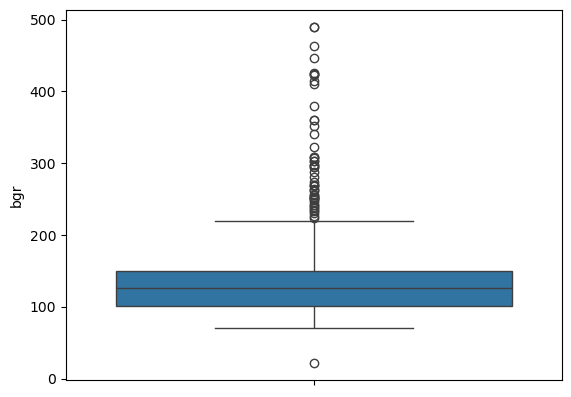

In [602]:
sns.boxplot(df['bgr'])

In [603]:
q3 = df['bgr'].quantile(0.75)
q1 = df['bgr'].quantile(0.25)
iqr = q3 - q1
print(q3), print(q1), print(q3 - q1)

150.0
101.0
49.0


(None, None, None)

In [604]:
upper_limit = q3 + 1.5*iqr
lower_limit = q1 - 1.5*iqr
print(upper_limit)
print(lower_limit)

223.5
27.5


In [605]:
df = df[(df['bgr'] >= lower_limit) & (df['bgr'] <= upper_limit)]

<Axes: ylabel='bgr'>

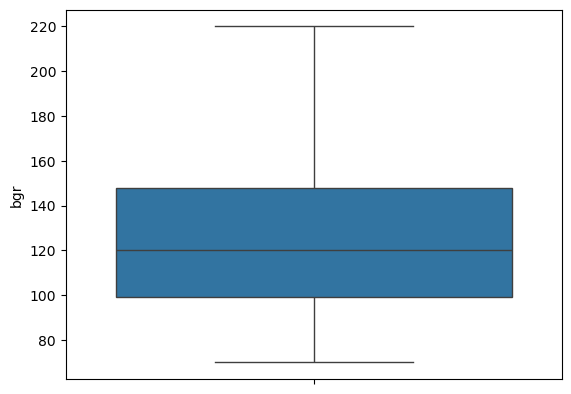

In [606]:
sns.boxplot(df['bgr'])

<Axes: ylabel='sc'>

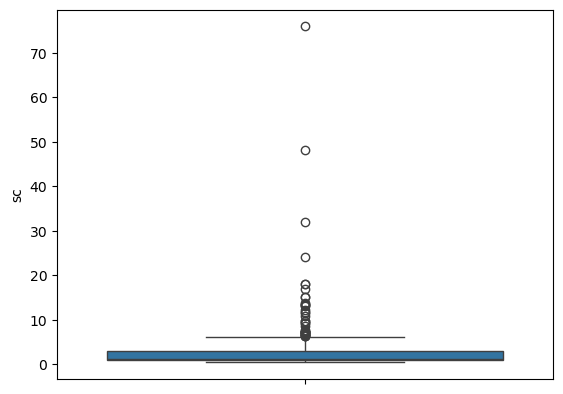

In [607]:
sns.boxplot(df['sc'])

In [608]:
q3 = df['sc'].quantile(0.75)
q1 = df['sc'].quantile(0.25)
iqr = q3 - q1
print(q3), 
print(q1), 
print(q3 - q1)

3.0362271540469976
0.9
2.1362271540469977


In [609]:
upper_limit = q3 + 1.5*iqr
lower_limit = q1 - 1.5*iqr
print(upper_limit)
print(lower_limit)

6.240567885117494
-2.304340731070497


In [610]:
df = df[(df['sc']<=upper_limit) & (df['sc']>=lower_limit)]

<Axes: ylabel='sc'>

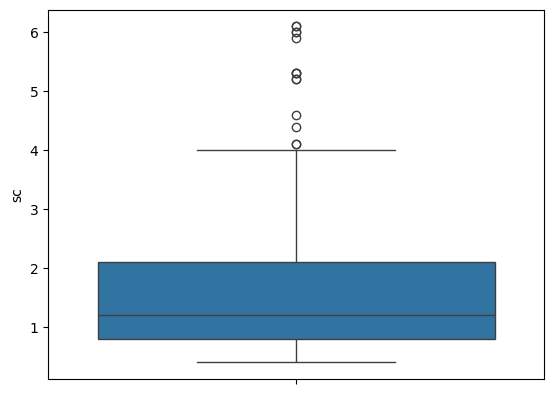

In [611]:
sns.boxplot(df['sc'])

In [612]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              308 non-null    int64  
 1   age             308 non-null    float64
 2   bp              308 non-null    float64
 3   sg              308 non-null    float64
 4   al              308 non-null    float64
 5   su              308 non-null    float64
 6   rbc             308 non-null    object 
 7   pc              308 non-null    object 
 8   pcc             308 non-null    object 
 9   ba              308 non-null    object 
 10  bgr             308 non-null    float64
 11  bu              308 non-null    float64
 12  sc              308 non-null    float64
 13  sod             308 non-null    float64
 14  pot             308 non-null    float64
 15  hemo            308 non-null    float64
 16  pcv             308 non-null    float64
 17  wc              308 non-null    float64


In [613]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,...,44.0,7800.0,5.200000,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,...,38.0,6000.0,4.707435,no,no,no,good,no,no,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.900000,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.600000,no,no,no,good,no,no,ckd
5,5,60.0,90.0,1.015,3.0,0.0,normal,normal,notpresent,notpresent,...,39.0,7800.0,4.400000,yes,yes,no,good,yes,no,ckd


In [614]:
ob_cols = df.select_dtypes("object").columns
ob_cols

Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification'],
      dtype='object')

In [615]:
df['rbc'] = 1 if df['rbc'].values[0] == 'normal' else 0
df['pc'] = 1 if df['pc'].values[0] == 'normal' else 0
df['pcc'] = 1 if df['pcc'].values[0] == 'present' else 0
df['ba'] = 1 if df['ba'].values[0] == 'present' else 0
df['htn'] = 1 if df['htn'].values[0] == 'yes' else 0
df['dm'] = 1 if df['dm'].values[0] == 'yes' else 0
df['cad'] = 1 if df['cad'].values[0] == 'yes' else 0
df['appet'] = 1 if df['appet'].values[0] == 'good' else 0
df['pe'] = 1 if df['pe'].values[0] == 'yes' else 0
df['ane'] = 1 if df['ane'].values[0] == 'yes' else 0
df['classification'] = 1 if df['classification'].values[0] == 'ckd' else 0

In [616]:
df.head(40)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020000,1.000000,0.000000,1,1,0,0,...,44.000000,7800.000000,5.200000,1,1,0,1,0,0,1
1,1,7.0,50.0,1.020000,4.000000,0.000000,1,1,0,0,...,38.000000,6000.000000,4.707435,1,1,0,1,0,0,1
3,3,48.0,70.0,1.005000,4.000000,0.000000,1,1,0,0,...,32.000000,6700.000000,3.900000,1,1,0,1,0,0,1
4,4,51.0,80.0,1.010000,2.000000,0.000000,1,1,0,0,...,35.000000,7300.000000,4.600000,1,1,0,1,0,0,1
5,5,60.0,90.0,1.015000,3.000000,0.000000,1,1,0,0,...,39.000000,7800.000000,4.400000,1,1,0,1,0,0,1
8,8,52.0,100.0,1.015000,3.000000,0.000000,1,1,0,0,...,33.000000,9600.000000,4.000000,1,1,0,1,0,0,1
12,12,68.0,70.0,1.015000,3.000000,1.000000,1,1,0,0,...,28.000000,12200.000000,3.400000,1,1,0,1,0,0,1
13,13,68.0,70.0,1.017408,1.016949,0.450142,1,1,0,0,...,38.884498,8406.122449,4.707435,1,1,0,1,0,0,1
14,14,68.0,80.0,1.010000,3.000000,2.000000,1,1,0,0,...,16.000000,11000.000000,2.600000,1,1,0,1,0,0,1
16,16,47.0,70.0,1.015000,2.000000,0.000000,1,1,0,0,...,38.884498,8406.122449,4.707435,1,1,0,1,0,0,1


In [617]:
df.loc[0]

id                   0.000000
age                 48.000000
bp                  80.000000
sg                   1.020000
al                   1.000000
su                   0.000000
rbc                  1.000000
pc                   1.000000
pcc                  0.000000
ba                   0.000000
bgr                121.000000
bu                  36.000000
sc                   1.200000
sod                137.528754
pot                  4.627244
hemo                15.400000
pcv                 44.000000
wc                7800.000000
rc                   5.200000
htn                  1.000000
dm                   1.000000
cad                  0.000000
appet                1.000000
pe                   0.000000
ane                  0.000000
classification       1.000000
Name: 0, dtype: float64

In [618]:
df = df.astype(float)

In [619]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              308 non-null    float64
 1   age             308 non-null    float64
 2   bp              308 non-null    float64
 3   sg              308 non-null    float64
 4   al              308 non-null    float64
 5   su              308 non-null    float64
 6   rbc             308 non-null    float64
 7   pc              308 non-null    float64
 8   pcc             308 non-null    float64
 9   ba              308 non-null    float64
 10  bgr             308 non-null    float64
 11  bu              308 non-null    float64
 12  sc              308 non-null    float64
 13  sod             308 non-null    float64
 14  pot             308 non-null    float64
 15  hemo            308 non-null    float64
 16  pcv             308 non-null    float64
 17  wc              308 non-null    float64


In [620]:
df['age'].min()

2.0

In [621]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [622]:
x = df[['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane']]
y = df['classification']

In [623]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x = sc.fit_transform(x)
x

array([[-0.10320398,  0.48749644,  0.31397072, ...,  0.        ,
         0.        ,  0.        ],
       [-2.40172214, -2.18528723,  0.31397072, ...,  0.        ,
         0.        ,  0.        ],
       [-0.10320398, -0.40343145, -2.51694728, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-2.12141504,  0.48749644,  0.31397072, ...,  0.        ,
         0.        ,  0.        ],
       [-1.84110795, -1.29435934,  1.25761006, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.45741021,  0.48749644,  1.25761006, ...,  0.        ,
         0.        ,  0.        ]])

In [624]:
from sklearn.model_selection import train_test_split

In [625]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state = 42)

In [626]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((215, 24), (93, 24), (215,), (93,))

In [627]:
x_train.unique()

AttributeError: 'numpy.ndarray' object has no attribute 'unique'

In [ ]:
y_train.unique()

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
classifier = LogisticRegression()

In [ ]:
classifier.fit(x_train, y_train)

In [ ]:
y_pred = classifier.predict(x_test)
y_pred

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
from sklearn import tree

In [ ]:
dtc = tree.DecisionTreeClassifier()

In [ ]:
dtc.fit(x, y)

In [ ]:
x_first = df.drop(['classification','id'], axis=1).iloc[[0]]  
dtc.predict(x_first)

In [ ]:
df[df["classification"]==0]

In [ ]:
df.loc[37]

In [ ]:
df.loc[0].values

In [ ]:
kidney_disease = pd.DataFrame([[4.80e+01, 8.00e+01, 1.00e+00, 1.00e+00, 0.00e+00,
                                   0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 1.21e+02, 3.60e+01,
                                   1.00e+00, 1.38e+02, 1.38e+02, 1.50e+01, 4.40e+01, 7.80e+03,
                                   5.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 1.00e+00,
                                   1.00e+00]], columns = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
                                                           'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
                                                           'appet', 'pe', 'ane'])

In [ ]:
kidney_disease

In [ ]:
sc.transform(kidney_disease)

In [ ]:
classifier.predict(kidney_disease)

In [ ]:
import pickle as pk

In [ ]:
pk.dump(sc,open("scaler_kidney.pkl",'wb'))
pk.dump(classifier,open("classifier_kidney.pkl",'wb'))